In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# df.describe(include="all")
df.describe() #only release_year has int64 datatype values

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

Director column contains many missing values because some titles may have multiple creators or unavailable metadata.

In [51]:
df.duplicated().sum()

np.int64(0)

# Separate Columns by Type

In [9]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
num_cols

Index(['release_year'], dtype='object')

Only column "releas_year" contains the numerical data & all other columns has objects type data

# 1) Univariate analysis

In [11]:
import seaborn as sns

## Type of the content on the Netflix

<Axes: xlabel='type', ylabel='count'>

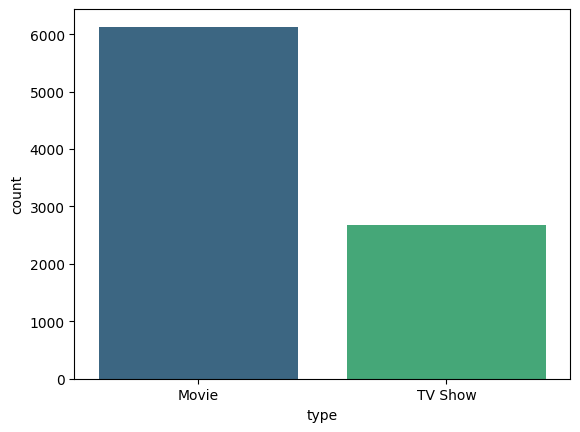

In [15]:
# 'hue' adds color based on the category, 'legend=False' hides the extra box
sns.countplot(data=df, x='type', hue='type', palette='viridis', legend=False)

Movies dominate the platform significantly more that TV Shows

In [53]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

## Release Year

<Axes: xlabel='release_year', ylabel='Count'>

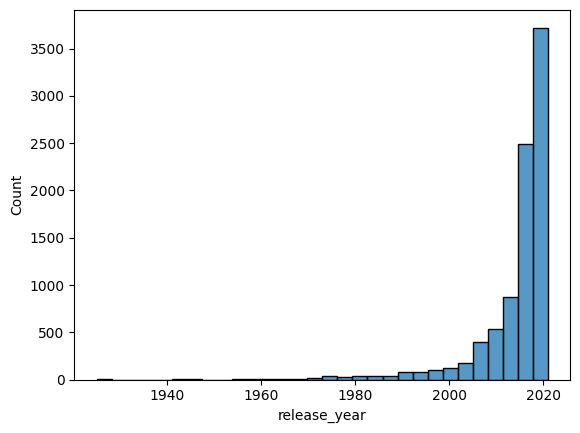

In [13]:
sns.histplot(df['release_year'], bins=30)

Netflix content increased rapidly after 2015

<Axes: xlabel='release_year'>

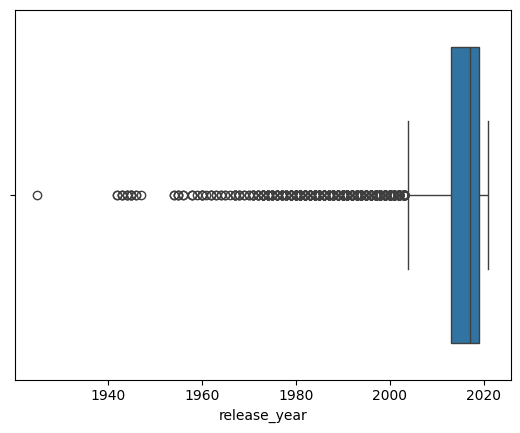

In [52]:
sns.boxplot(x=df['release_year'])

# Which countries produce the most content?

In [44]:
# Top countries producing Netflix content

# Split countries because some rows contain multiple countries
country_series = (
    df['country']
    .dropna()   #remove missing values
    .str.split(', ')   #split multiple countries into lists
    .explode()         #convert list items into separate rows
)

# Count content by country
top_countries = country_series.value_counts().head(10)  #count each country and keep top 10 country

# Display values
print(top_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


<Axes: xlabel='country'>

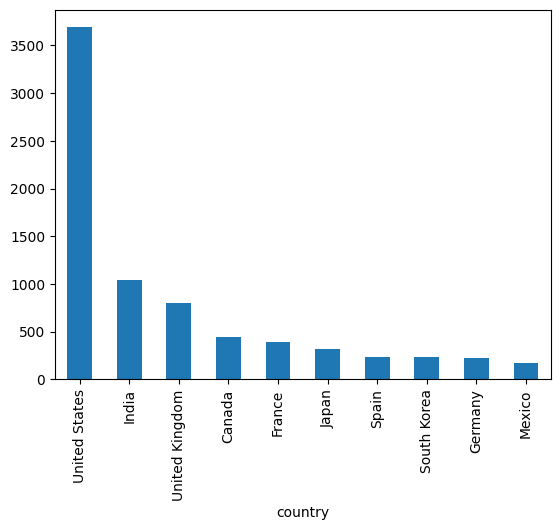

In [45]:
top_countries.plot(kind='bar')

In [49]:
# Genres
genre_series = (
    df['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
)
genres = genre_series.value_counts().head(10)

# Display values
print(genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


<Axes: xlabel='listed_in'>

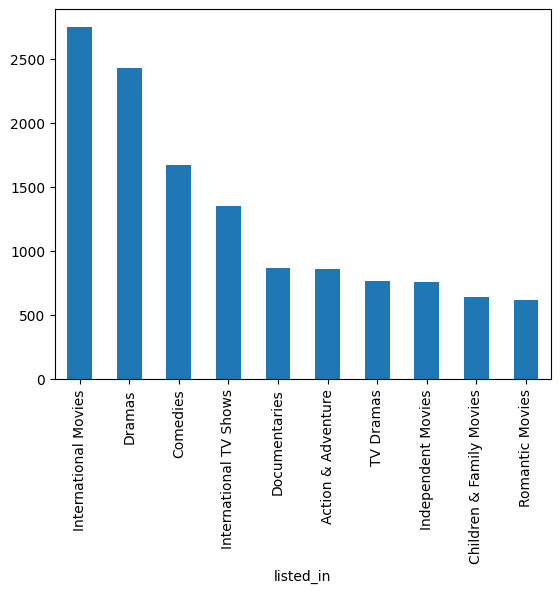

In [50]:
genres.plot(kind='bar')

The listed_in column represents content genres and categories. Analysis shows that International Movies and Dramas dominate the Netflix catalog.

## Rating analysis

In [57]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

<Axes: xlabel='rating'>

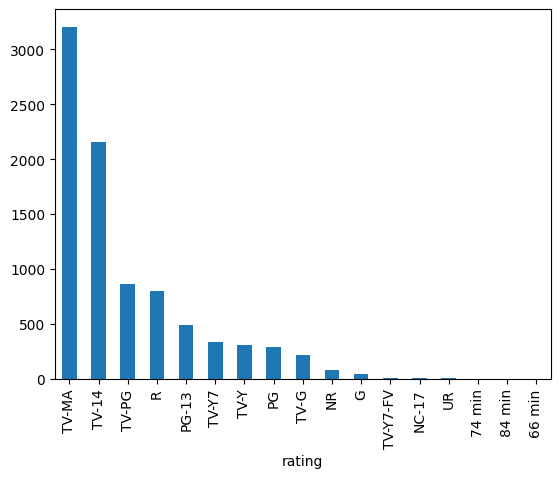

In [70]:
# sns.countplot(data=df, y='rating', hue='rating')
df['rating'].value_counts().plot(kind='bar')

## Duration analysis

## Description length

<Axes: xlabel='description_length', ylabel='Count'>

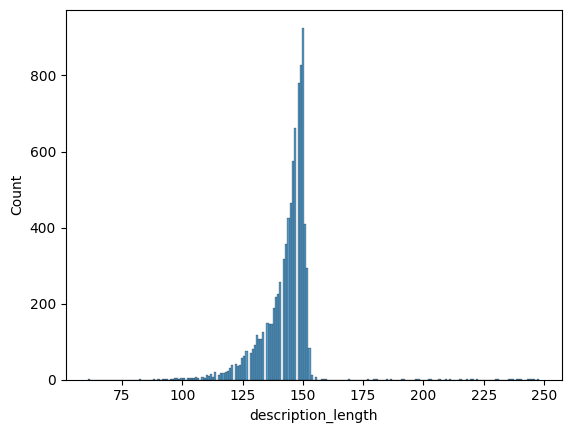

In [74]:
df['description_length'] = (
    df['description']
    .str.len()
)
sns.histplot(df['description_length'])

## Unique value analysis

In [75]:
df.nunique().sort_values(ascending=False)

show_id               8807
title                 8807
description           8775
cast                  7692
director              4528
date_added            1767
country                748
listed_in              514
duration               220
description_length     104
release_year            74
rating                  17
type                     2
dtype: int64

# Bivariate Analysis

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64
